# VGG16 Image Classification

In [ ]:
# Build the vgg16 model (https://arxiv.org/abs/1409.1556). It is your choice whether you design
# the VGG16 from scratch or download the VGG model from the torchvision. However, additional
# marks are given if the vgg16 model is created from scratch.

# As per question 1, use the cross-entropy loss function, and the SGD optimizer. The batch size and the learning rate
# are set at 32 and 0.01 respectively. Train your model in the training set and evaluate your model in the
# testing set. Train and evaluate your model using three datasets: MNIST, CIFAR10, CIFAR100.
# Include visualization to show the predictive performance of your method

## Section 1 — Imports and Setup

In [ ]:
# ============================================
# Import and setup
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import random

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## Section 2 — Global Visualization

In [ ]:
# ============================================
# Visualization Style
# ============================================

PALETTE = {
    "loss":          "#8E1B1B",  # deep classic red
    "accuracy":      "#1F4E79",  # navy blue
    "bar_primary":   "#2E5C6E",  # slate teal
    "bar_secondary": "#8E1B1B",
    "grid":          "#B0B0B0",
    "correct":       "#1B7837",  # forest green
    "incorrect":     "#B2182B",  # crimson
}

plt.rcParams.update({
    # Fonts — classic serif, bold headings
    "font.family":        "serif",
    "font.serif":         ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size":          13,

    # Titles & axis labels
    "axes.titlesize":     17,
    "axes.titleweight":   "bold",
    "axes.labelsize":     14,
    "axes.labelweight":   "bold",
    "figure.titlesize":   19,
    "figure.titleweight": "bold",

    # Tick labels
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # Legend
    "legend.fontsize":    12,
    "legend.frameon":     True,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#333333",

    # Axes & grid — clean, classic look
    "axes.facecolor":     "#FAFAFA",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     1.3,
    "grid.color":         PALETTE["grid"],
    "grid.linestyle":     "--",
    "grid.alpha":         0.55,
    "axes.grid":          True,

    # Figure
    "figure.facecolor":   "white",
    "figure.dpi":         110,
    "savefig.dpi":        160,
})

print("Global plot style applied: classic serif theme with bold titles/labels.")


Global plot style applied: classic serif theme with bold titles/labels.


## Section 3 — Training Configuration

In [ ]:
# ============================================
# Assigning training settings
# ============================================

BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 10

print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)


Batch size: 32
Learning rate: 0.01
Epochs: 10


## Section 4 — Dataset Preprocessing.

In [ ]:
# MNIST contains 28×28 grayscale handwritten digits, while CIFAR-10 and CIFAR-100 contain 32×32 RGB images.

# The images are converted to tensors and normalized using standard dataset statistics. For VGG16, MNIST is later converted from one
# channel to three channels so that the same VGG-style architecture can process all three datasets

In [ ]:
# ============================================
# Loading Dataset
# ============================================

# MNIST
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

mnist_train_loader = DataLoader(
    mnist_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

mnist_classes = [str(i) for i in range(10)]


# CIFAR-10
cifar10_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

cifar10_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cifar10_transform
)

cifar10_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cifar10_transform
)

cifar10_train_loader = DataLoader(
    cifar10_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cifar10_test_loader = DataLoader(
    cifar10_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

cifar10_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


# CIFAR-100
cifar100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5071, 0.4867, 0.4408),
        (0.2675, 0.2565, 0.2761)
    )
])

cifar100_train = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=cifar100_transform
)

cifar100_test = datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=cifar100_transform
)

cifar100_train_loader = DataLoader(
    cifar100_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cifar100_test_loader = DataLoader(
    cifar100_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

cifar100_classes = cifar100_train.classes

print("MNIST:", len(mnist_train), "training images,", len(mnist_test), "test images")
print("CIFAR-10:", len(cifar10_train), "training images,", len(cifar10_test), "test images")
print("CIFAR-100:", len(cifar100_train), "training images,", len(cifar100_test), "test images")


100%|██████████| 170M/170M [13:03<00:00, 218kB/s]
100%|██████████| 169M/169M [14:07<00:00, 200kB/s]


MNIST: 60000 training images, 10000 test images
CIFAR-10: 50000 training images, 10000 test images
CIFAR-100: 50000 training images, 10000 test images


## Section 5: Visualising images

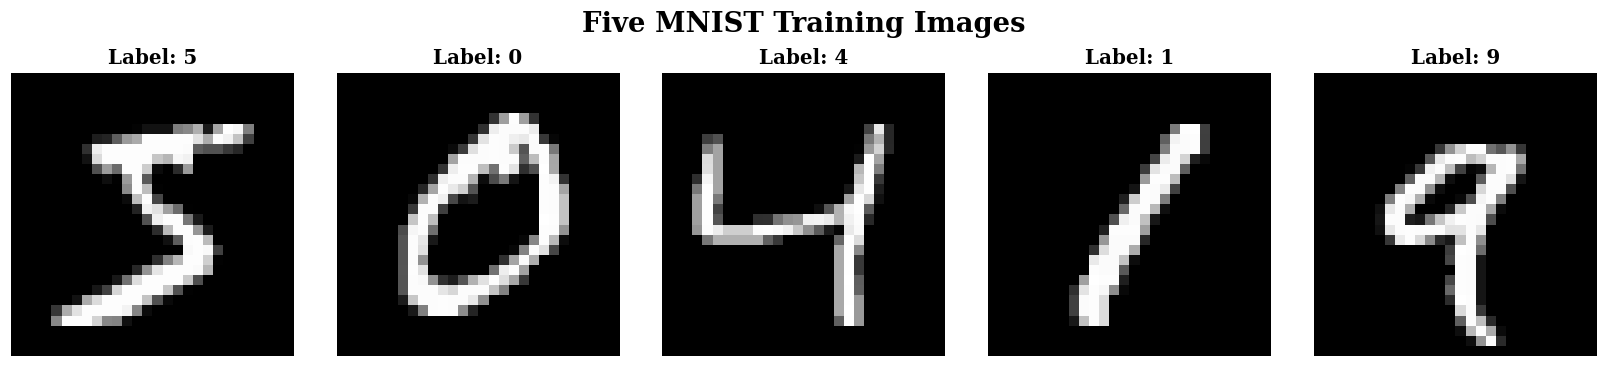

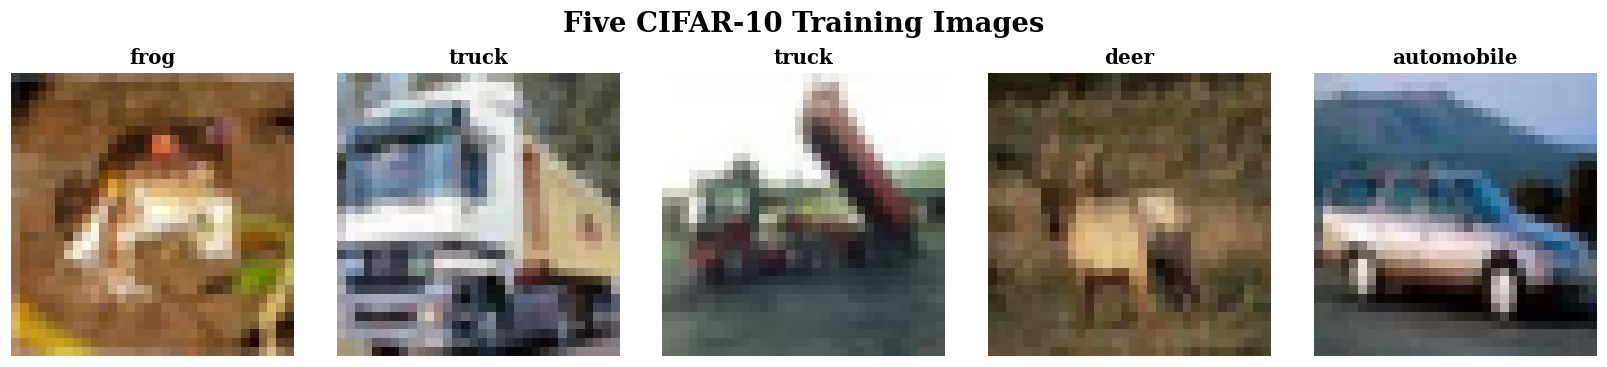

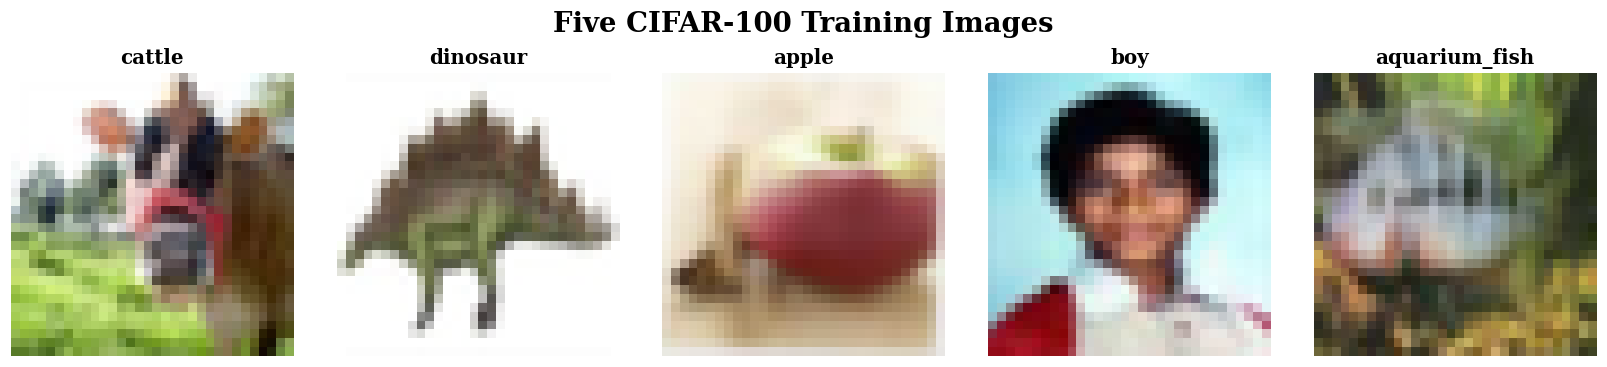

In [ ]:
# ============================================
# Images from each datasets
# ============================================


fig = plt.figure(figsize=(15, 3.4))

for i in range(5):
    image, label = mnist_train[i]
    image = image * 0.3081 + 0.1307

    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}", fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Five MNIST Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


mean10 = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std10 = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

fig = plt.figure(figsize=(15, 3.4))

for i in range(5):
    image, label = cifar10_train[i]
    image = torch.clamp(image * std10 + mean10, 0, 1)

    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(cifar10_classes[label], fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Five CIFAR-10 Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


mean100 = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
std100 = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)

fig = plt.figure(figsize=(15, 3.4))

for i in range(5):
    image, label = cifar100_train[i]
    image = torch.clamp(image * std100 + mean100, 0, 1)

    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(cifar100_classes[label], fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Five CIFAR-100 Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


## Section 6 — VGG16 Architecture

In [ ]:
# The original VGG16 architecture contains 13 convolutional layers and 3 fully connected layers. The convolutional blocks use 3×3 filters
# and ReLU activations, with max-pooling used between blocks.

# Because MNIST and CIFAR images are much smaller than the original ImageNet input, the classifier is adapted to avoid excessive spatial downsampling.
# The convolutional feature extractor retains the VGG16-style sequence of five convolutional blocks.

# The network below accepts three-channel images and uses adaptive average pooling before the classifier. Adaptive pooling makes the classifier independent
# of the exact spatial dimensions produced by the convolutional blocks.

In [ ]:
# ============================================
# VGG16 implementation for small images
# ============================================

class VGG16Scratch(nn.Module):
    def __init__(self, num_classes):
        super(VGG16Scratch, self).__init__()

        # VGG16-style architecture:
        # Block 1: 2 convolutional layers
        # Block 2: 2 convolutional layers
        # Block 3: 3 convolutional layers
        # Block 4: 3 convolutional layers
        # Block 5: 3 convolutional layers
        # Total = 13 convolutional layers

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # Adaptive pooling makes the classifier independent
        # of the small input image size.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Check model
test_model = VGG16Scratch(num_classes=10).to(device)

print(test_model)

total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(
    p.numel() for p in test_model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

VGG16Scratch(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d

## Section 7 — Preparing MNIST for VGG16

In [ ]:
# VGG16 expects three-channel input. MNIST contains one grayscale channel. Therefore, the MNIST tensor is replicated
# across the three channels.

# This does not create new information; it simply changes the input shape from `(1, 28, 28)` to `(3, 28, 28)` so that
# the VGG16 convolutional layers can process it.

In [ ]:
# ============================================
# Converting MNIST to 3 channels
# ============================================

mnist_vgg_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.1307, 0.1307, 0.1307),
                         (0.3081, 0.3081, 0.3081))
])

mnist_vgg_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_vgg_transform
)

mnist_vgg_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_vgg_transform
)

mnist_vgg_train_loader = DataLoader(
    mnist_vgg_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

mnist_vgg_test_loader = DataLoader(
    mnist_vgg_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("MNIST VGG input shape:", mnist_vgg_train[0][0].shape)


MNIST VGG input shape: torch.Size([3, 28, 28])


## Section 8 — Training and Evaluation Functions

In [ ]:
# ============================================
# Training function for VGG16
# ============================================


def train_vgg_model(model, train_loader, criterion, optimizer, epochs=10):

    model.train()

    epoch_losses = []
    epoch_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):

        running_loss = 0.0
        correct = 0
        total = 0

        model.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total

        epoch_losses.append(epoch_loss)
        epoch_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    return epoch_losses, epoch_accuracies, training_time


## Section 9: Evaluation function

In [ ]:
# ============================================
# Training function for VGG16
# ============================================

def evaluate_vgg_model(model, test_loader):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }


## Section 10 — Visualization Functions

In [ ]:
# ============================================
# Training visualisation
# ============================================

def plot_vgg_training_history(losses, accuracies, dataset_name):

    epochs = range(1, len(losses) + 1)

    # ----------------------------------------
    # GRAPH 1 - TRAINING LOSS
    # ----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs, losses,
        marker="o", linewidth=2.5, markersize=8,
        color=PALETTE["loss"], markerfacecolor="white",
        markeredgewidth=2, markeredgecolor=PALETTE["loss"],
    )
    plt.fill_between(epochs, losses, alpha=0.12, color=PALETTE["loss"])

    plt.title(f"VGG16 Training Loss — {dataset_name}", pad=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(list(epochs))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 2 - TRAINING ACCURACY
    # ----------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs, accuracies,
        marker="o", linewidth=2.5, markersize=8,
        color=PALETTE["accuracy"], markerfacecolor="white",
        markeredgewidth=2, markeredgecolor=PALETTE["accuracy"],
    )
    plt.fill_between(epochs, accuracies, alpha=0.12, color=PALETTE["accuracy"])

    plt.title(f"VGG16 Training Accuracy — {dataset_name}", pad=14)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.xticks(list(epochs))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 3 - LOSS + ACCURACY (DUAL AXIS)
    # ----------------------------------------
    fig, ax1 = plt.subplots(figsize=(9, 5))

    line1, = ax1.plot(
        epochs, losses,
        marker="o", linewidth=2.5, markersize=7,
        color=PALETTE["loss"], label="Loss",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color=PALETTE["loss"], fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=PALETTE["loss"])

    ax2 = ax1.twinx()
    line2, = ax2.plot(
        epochs, accuracies,
        marker="s", linewidth=2.5, markersize=7,
        color=PALETTE["accuracy"], label="Accuracy",
    )
    ax2.set_ylabel("Accuracy (%)", color=PALETTE["accuracy"], fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=PALETTE["accuracy"])
    ax2.grid(False)

    ax1.set_xticks(list(epochs))
    ax1.legend(handles=[line1, line2], loc="center right")

    plt.title(f"VGG16 Loss and Accuracy — {dataset_name}", pad=14)
    fig.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 4 - ACCURACY CHANGE PER EPOCH
    # ----------------------------------------
    accuracy_change = np.diff([accuracies[0]] + accuracies)

    plt.figure(figsize=(8, 5))

    bar_colors = [PALETTE["correct"] if v >= 0 else PALETTE["incorrect"] for v in accuracy_change]

    bars = plt.bar(
        list(epochs), accuracy_change,
        color=bar_colors, edgecolor="black", linewidth=0.8,
    )

    for bar, value in zip(bars, accuracy_change):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.1f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10, fontweight="bold",
        )

    plt.title(f"Accuracy Change per Epoch — {dataset_name}", pad=14)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy Change (%)")
    plt.xticks(list(epochs))
    plt.grid(axis="y")
    plt.axhline(0, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 5 - LOSS REDUCTION PER EPOCH
    # ----------------------------------------
    loss_change = np.diff([losses[0]] + losses) * -1

    plt.figure(figsize=(8, 5))

    bar_colors = [PALETTE["correct"] if v >= 0 else PALETTE["incorrect"] for v in loss_change]

    bars = plt.bar(
        list(epochs), loss_change,
        color=bar_colors, edgecolor="black", linewidth=0.8,
    )

    for bar, value in zip(bars, loss_change):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.3f}", ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10, fontweight="bold",
        )

    plt.title(f"Loss Reduction per Epoch — {dataset_name}", pad=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss Reduction")
    plt.xticks(list(epochs))
    plt.grid(axis="y")
    plt.axhline(0, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()


## Section 10 — Confusion Matrix

In [ ]:
# ============================================
# CONFUSION MATRIX
# ============================================

def plot_vgg_confusion_matrix(cm, class_names, dataset_name):

    n_classes = len(class_names)

    # Scale figure size / label density to the number of classes so a
    # 10-class matrix (MNIST, CIFAR-10) stays richly annotated while the
    # 100-class CIFAR-100 matrix stays readable instead of turning into
    # an unreadable wall of overlapping numbers.
    if n_classes <= 20:
        fig_size = (10, 8)
        show_values = True
        tick_fontsize = 11
    else:
        fig_size = (18, 16)
        show_values = False
        tick_fontsize = 7

    fig, ax = plt.subplots(figsize=fig_size)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format="d" if show_values else None,
        include_values=show_values,
        colorbar=True,
    )

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=tick_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)

    ax.set_title(
        f"VGG16 Confusion Matrix — {dataset_name}",
        fontsize=17, fontweight="bold", pad=16,
    )
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")

    plt.tight_layout()
    plt.show()


## Section 11 — Random Image Prediction

In [ ]:
# ============================================
# RANDOM IMAGE PREDICTION
# ============================================

def random_vgg_predictions(model, dataset, class_names, dataset_name, num_images=5):

    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(15, 3.6))

    for position, index in enumerate(indices):

        image, label = dataset[index]

        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_image)
            probabilities = torch.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)

        is_correct = prediction.item() == label
        result_color = PALETTE["correct"] if is_correct else PALETTE["incorrect"]

        # Convert image back for display
        display_image = image.clone()

        if dataset_name == "MNIST":
            mean = torch.tensor([0.1307, 0.1307, 0.1307]).view(3, 1, 1)
            std = torch.tensor([0.3081, 0.3081, 0.3081]).view(3, 1, 1)
        elif dataset_name == "CIFAR-10":
            mean = mean10
            std = std10
        else:
            mean = mean100
            std = std100

        display_image = torch.clamp(display_image * std + mean, 0, 1)

        ax = plt.subplot(1, num_images, position + 1)

        if display_image.shape[0] == 3:
            ax.imshow(display_image.permute(1, 2, 0))
        else:
            ax.imshow(display_image.squeeze(), cmap="gray")

        ax.set_title(
            f"Actual: {class_names[label]}\n"
            f"Pred: {class_names[prediction.item()]}\n"
            f"Confidence: {confidence.item()*100:.1f}%",
            fontsize=11, fontweight="bold", color=result_color,
        )

        ax.axis("off")

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(result_color)
            spine.set_linewidth(4)

    plt.suptitle(f"Five Random VGG16 Predictions — {dataset_name}", fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()


## Section 12 — VGG16 on MNIST

The VGG16 model is trained on MNIST for 10 epochs using SGD, a learning rate of 0.01, batch size 32, and cross-entropy loss.

### MNIST — Training

In [ ]:
# ============================================
# Training VGG16 on MNIST
# ============================================

mnist_vgg_model = VGG16Scratch(num_classes=10).to(device)

mnist_vgg_criterion = nn.CrossEntropyLoss()

mnist_vgg_optimizer = optim.SGD(
    mnist_vgg_model.parameters(),
    lr=LEARNING_RATE
)

mnist_vgg_losses, mnist_vgg_accuracies, mnist_vgg_training_time = train_vgg_model(
    mnist_vgg_model,
    mnist_vgg_train_loader,
    mnist_vgg_criterion,
    mnist_vgg_optimizer,
    epochs=EPOCHS
)

print(f"MNIST VGG16 Training Time: {mnist_vgg_training_time:.2f} seconds")


Epoch [1/10] Loss: 0.1660 Accuracy: 96.45%
Epoch [2/10] Loss: 0.0364 Accuracy: 98.98%
Epoch [3/10] Loss: 0.0228 Accuracy: 99.37%
Epoch [4/10] Loss: 0.0166 Accuracy: 99.51%
Epoch [5/10] Loss: 0.0100 Accuracy: 99.75%
Epoch [6/10] Loss: 0.0080 Accuracy: 99.77%
Epoch [7/10] Loss: 0.0071 Accuracy: 99.80%
Epoch [8/10] Loss: 0.0043 Accuracy: 99.87%
Epoch [9/10] Loss: 0.0041 Accuracy: 99.87%
Epoch [10/10] Loss: 0.0026 Accuracy: 99.92%
MNIST VGG16 Training Time: 553.84 seconds


### MNIST — Evaluation

In [ ]:
# ============================================
# Evaluate VGG16 on MNIST
# ============================================

mnist_vgg_results = evaluate_vgg_model(
    mnist_vgg_model,
    mnist_vgg_test_loader
)

print(f"Accuracy:  {mnist_vgg_results['accuracy']*100:.2f}%")
print(f"Precision: {mnist_vgg_results['precision']*100:.2f}%")
print(f"Recall:    {mnist_vgg_results['recall']*100:.2f}%")
print(f"F1-score:  {mnist_vgg_results['f1']*100:.2f}%")


Accuracy:  99.42%
Precision: 99.41%
Recall:    99.42%
F1-score:  99.42%


### MNIST — Visualizations

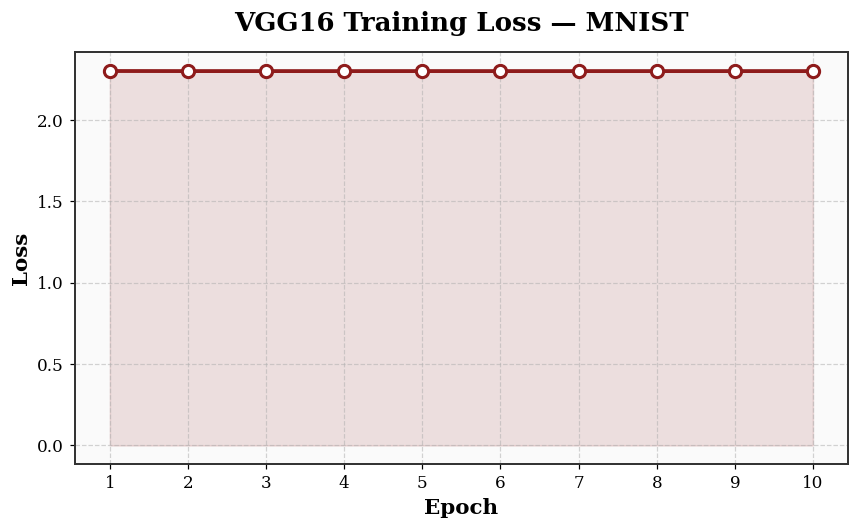

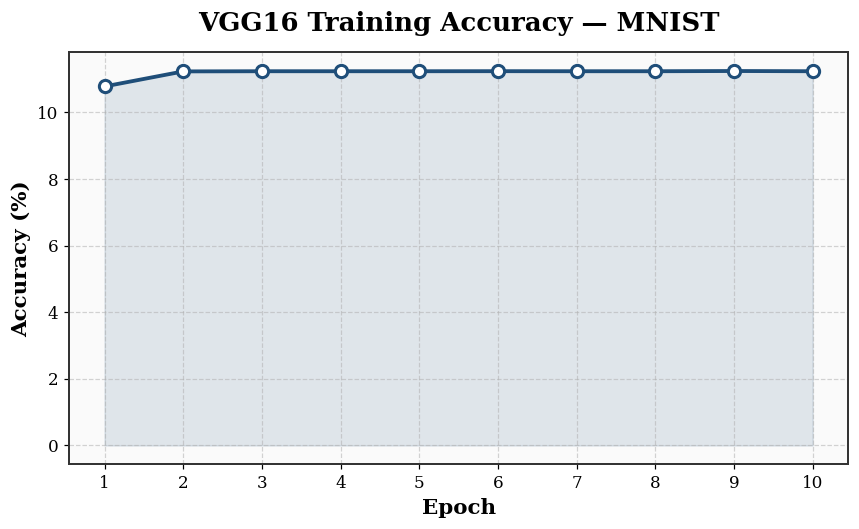

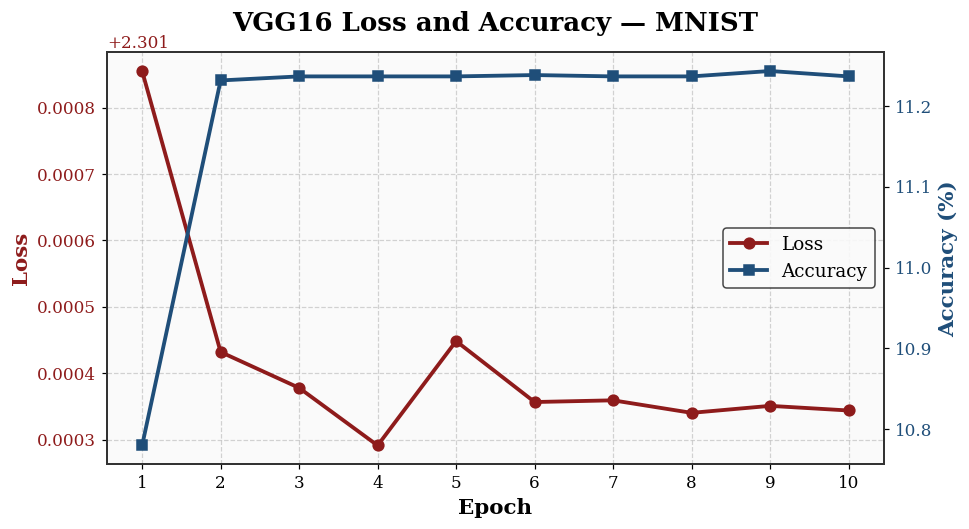

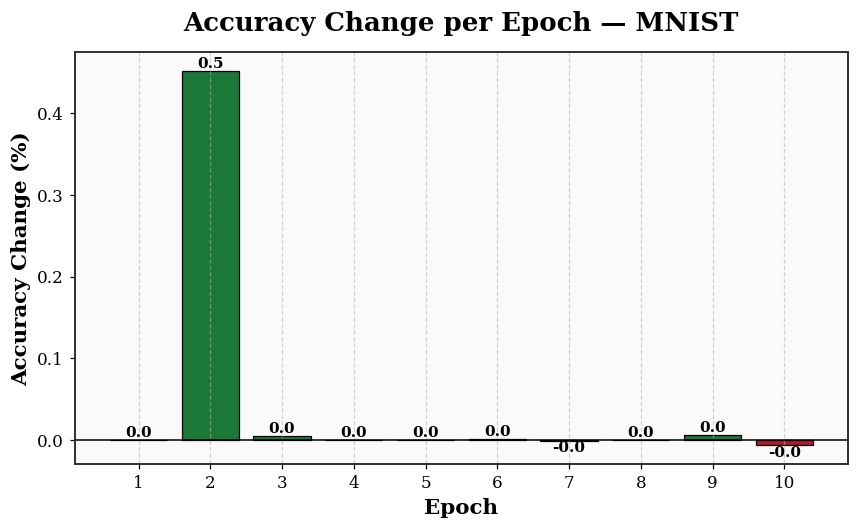

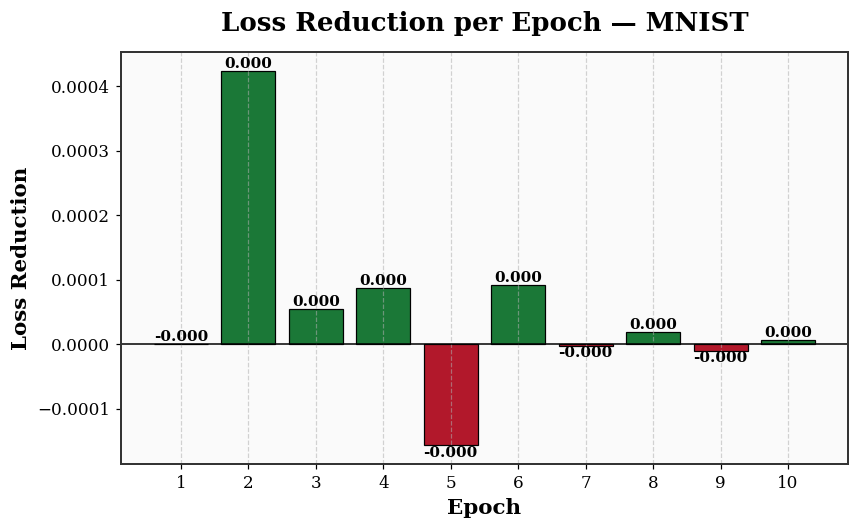

In [ ]:
# ============================================
# MNIST Visualization
# ============================================

plot_vgg_training_history(
    mnist_vgg_losses,
    mnist_vgg_accuracies,
    "MNIST"
)


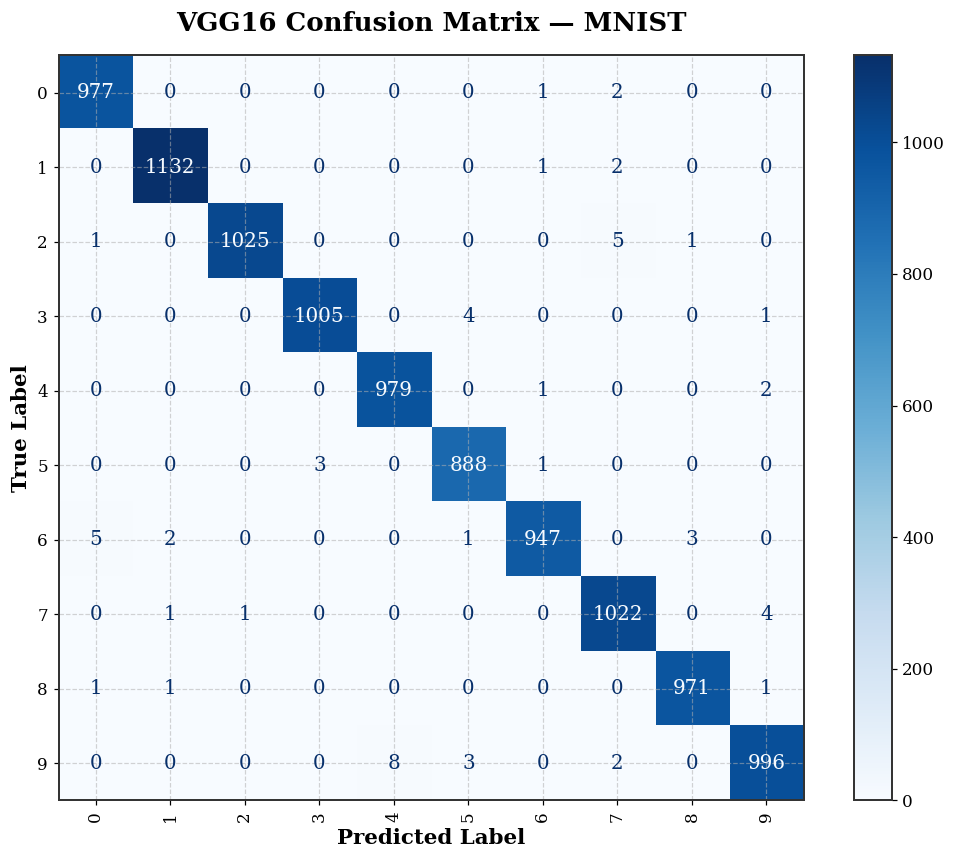

In [ ]:
plot_vgg_confusion_matrix(
    mnist_vgg_results["confusion_matrix"],
    mnist_classes,
    "MNIST"
)

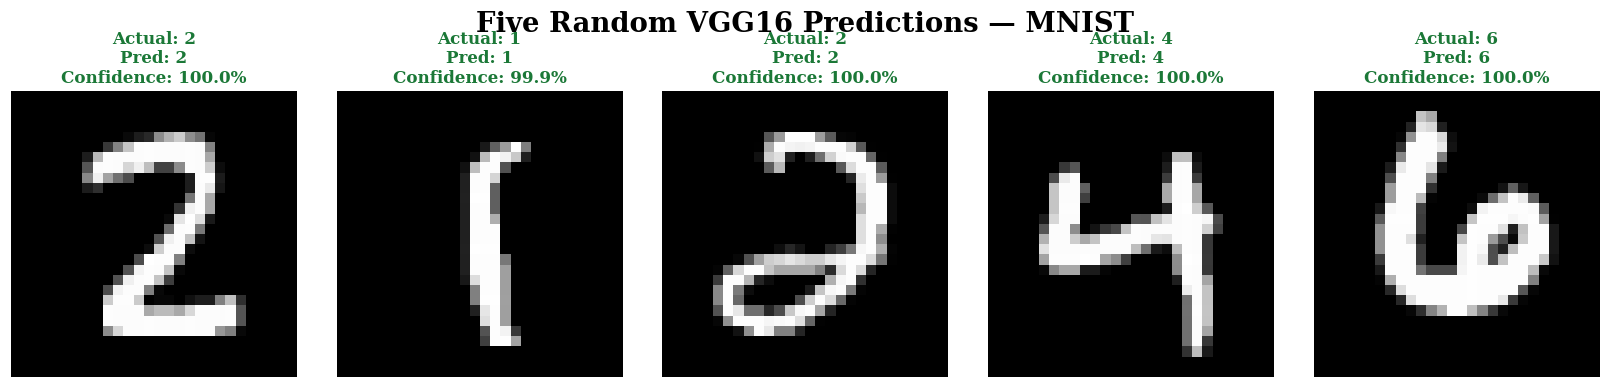

In [ ]:
random_vgg_predictions(
    mnist_vgg_model,
    mnist_vgg_test,
    mnist_classes,
    "MNIST"
)

## Section 13 — VGG16 on CIFAR-10

### CIFAR-10 — Training

In [ ]:
# ============================================
# TrAINING CIFAR 10 on dataset
# ============================================

cifar10_vgg_model = VGG16Scratch(num_classes=10).to(device)

cifar10_vgg_criterion = nn.CrossEntropyLoss()

cifar10_vgg_optimizer = optim.SGD(
    cifar10_vgg_model.parameters(),
    lr=LEARNING_RATE
)

cifar10_vgg_losses, cifar10_vgg_accuracies, cifar10_vgg_training_time = train_vgg_model(
    cifar10_vgg_model,
    cifar10_train_loader,
    cifar10_vgg_criterion,
    cifar10_vgg_optimizer,
    epochs=EPOCHS
)

print(f"CIFAR-10 VGG16 Training Time: {cifar10_vgg_training_time:.2f} seconds")


Epoch [1/10] Loss: 1.2973 Accuracy: 53.07%
Epoch [2/10] Loss: 0.7778 Accuracy: 72.95%
Epoch [3/10] Loss: 0.5663 Accuracy: 80.56%
Epoch [4/10] Loss: 0.4315 Accuracy: 85.43%
Epoch [5/10] Loss: 0.3218 Accuracy: 89.03%
Epoch [6/10] Loss: 0.2452 Accuracy: 91.45%
Epoch [7/10] Loss: 0.1864 Accuracy: 93.56%
Epoch [8/10] Loss: 0.1358 Accuracy: 95.40%
Epoch [9/10] Loss: 0.1101 Accuracy: 96.22%
Epoch [10/10] Loss: 0.0864 Accuracy: 96.95%
CIFAR-10 VGG16 Training Time: 445.08 seconds


### CIFAR-10 — Evaluation

In [ ]:
# ============================================
# Evaluate VGG16 on CIFAR-10
# ============================================\



cifar10_vgg_results = evaluate_vgg_model(
    cifar10_vgg_model,
    cifar10_test_loader
)

print(f"Accuracy:  {cifar10_vgg_results['accuracy']*100:.2f}%")
print(f"Precision: {cifar10_vgg_results['precision']*100:.2f}%")
print(f"Recall:    {cifar10_vgg_results['recall']*100:.2f}%")
print(f"F1-score:  {cifar10_vgg_results['f1']*100:.2f}%")


Accuracy:  81.67%
Precision: 82.25%
Recall:    81.67%
F1-score:  81.58%


### CIFAR-10 — Visualizations

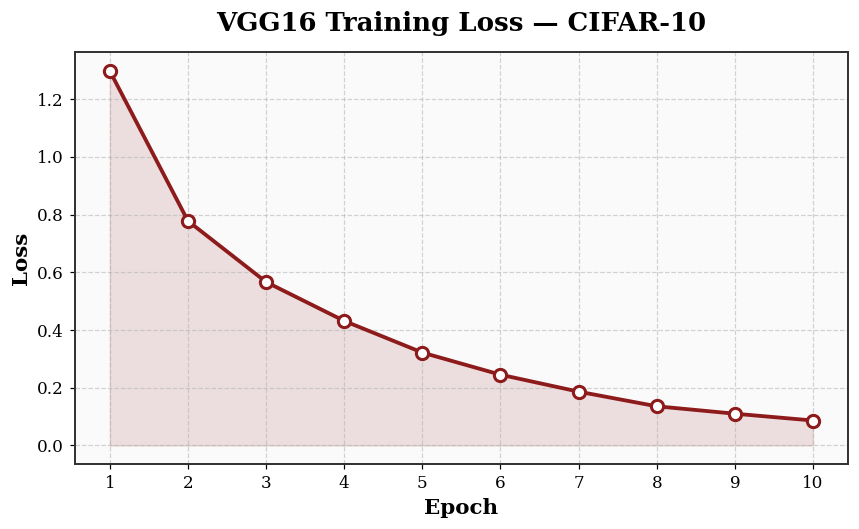

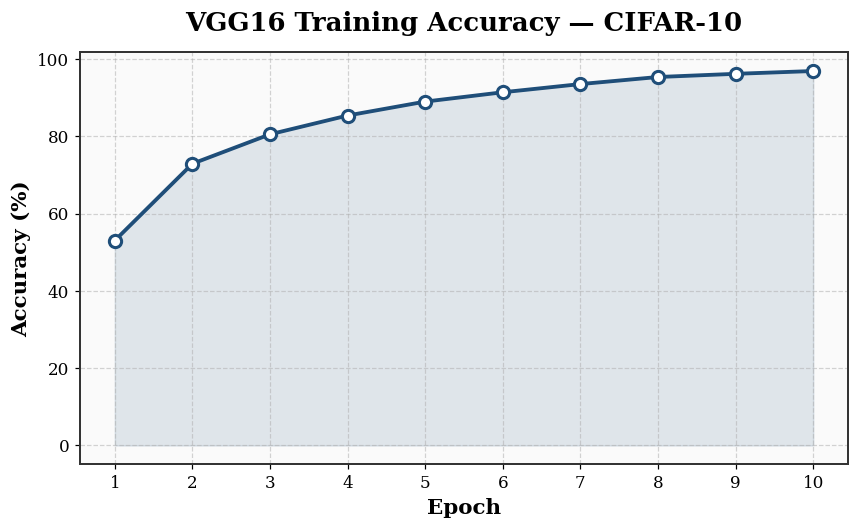

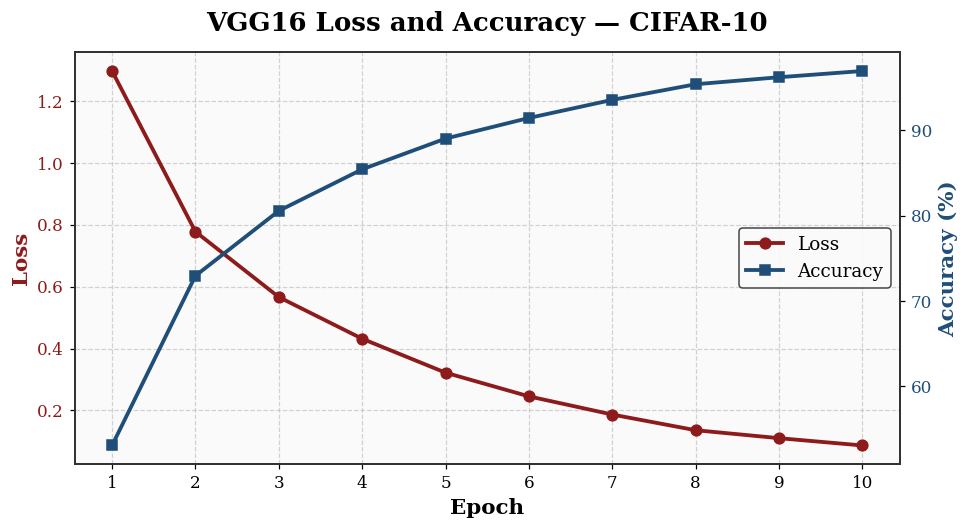

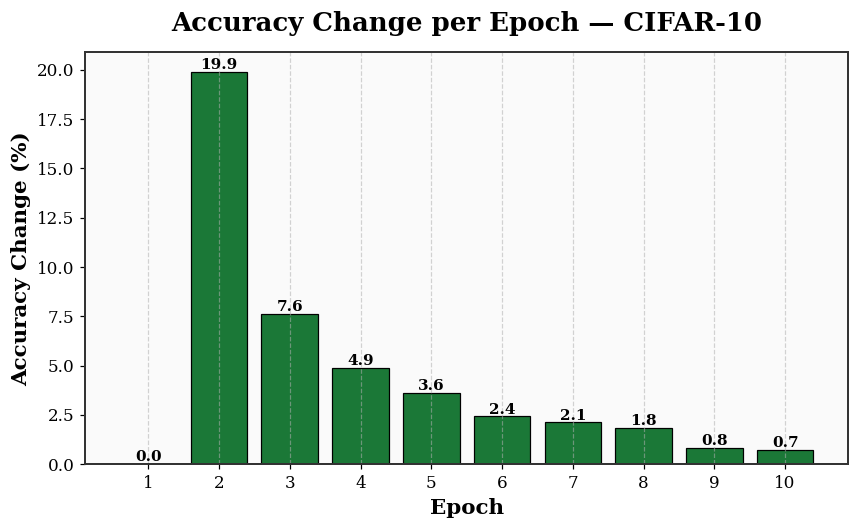

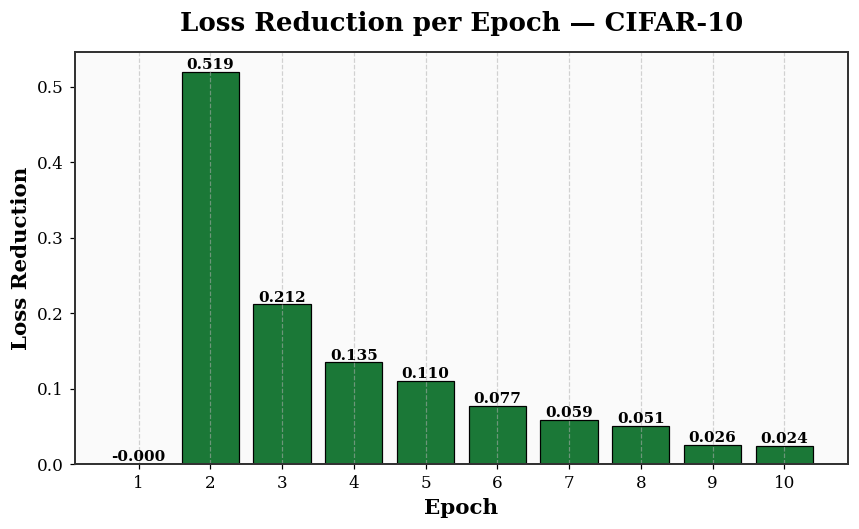

In [ ]:
# ============================================
# CIFAR-10 visualisations
# ============================================

plot_vgg_training_history(
    cifar10_vgg_losses,
    cifar10_vgg_accuracies,
    "CIFAR-10"
)


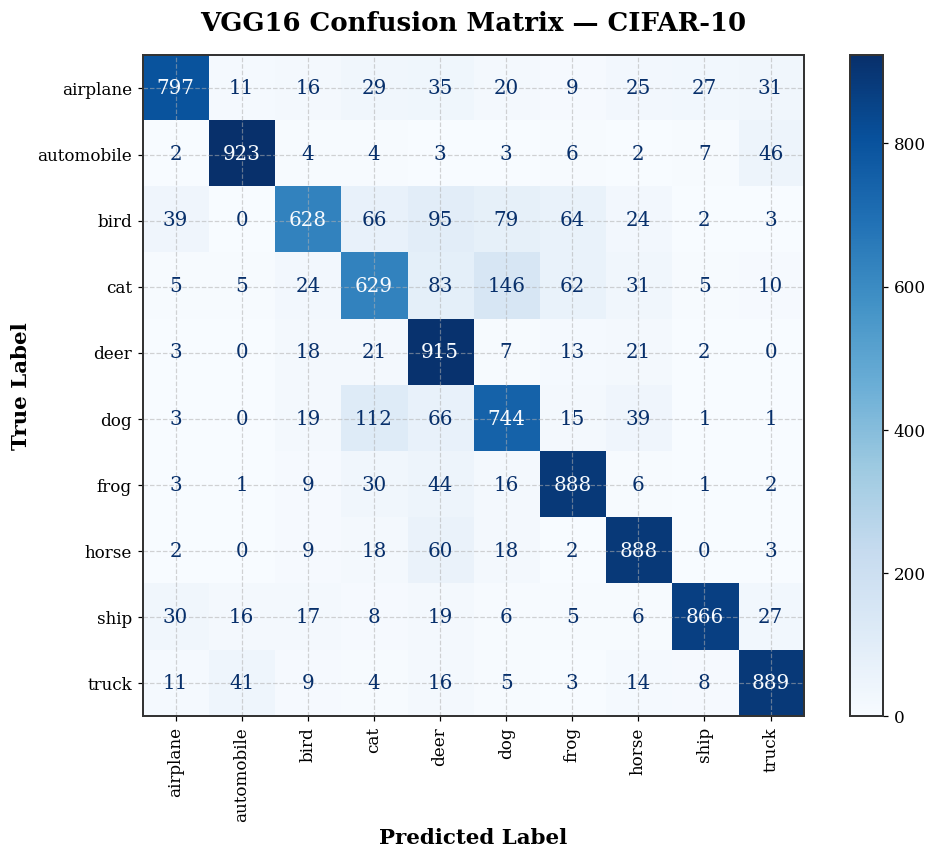

In [ ]:
plot_vgg_confusion_matrix(
    cifar10_vgg_results["confusion_matrix"],
    cifar10_classes,
    "CIFAR-10"
)

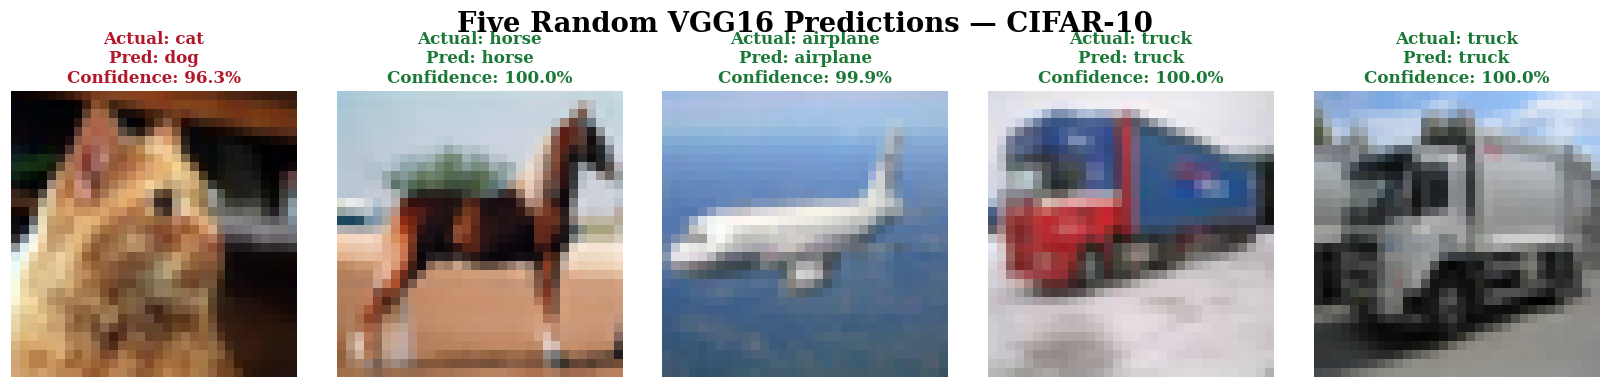

In [ ]:
random_vgg_predictions(
    cifar10_vgg_model,
    cifar10_test,
    cifar10_classes,
    "CIFAR-10"
)

## Section 14 — VGG16 on CIFAR-100

### CIFAR-100 — Training

In [ ]:
# ============================================
# Train VGG16 on CIFAR-100
# ============================================

cifar100_vgg_model = VGG16Scratch(num_classes=100).to(device)

cifar100_vgg_criterion = nn.CrossEntropyLoss()

cifar100_vgg_optimizer = optim.SGD(
    cifar100_vgg_model.parameters(),
    lr=LEARNING_RATE
)

cifar100_vgg_losses, cifar100_vgg_accuracies, cifar100_vgg_training_time = train_vgg_model(
    cifar100_vgg_model,
    cifar100_train_loader,
    cifar100_vgg_criterion,
    cifar100_vgg_optimizer,
    epochs=EPOCHS
)

print(f"CIFAR-100 VGG16 Training Time: {cifar100_vgg_training_time:.2f} seconds")


Epoch [1/10] Loss: 4.0014 Accuracy: 9.29%
Epoch [2/10] Loss: 3.1183 Accuracy: 22.50%
Epoch [3/10] Loss: 2.5121 Accuracy: 34.18%
Epoch [4/10] Loss: 2.1039 Accuracy: 43.11%
Epoch [5/10] Loss: 1.7973 Accuracy: 50.18%
Epoch [6/10] Loss: 1.5338 Accuracy: 56.53%
Epoch [7/10] Loss: 1.3110 Accuracy: 61.96%
Epoch [8/10] Loss: 1.0862 Accuracy: 67.63%
Epoch [9/10] Loss: 0.8993 Accuracy: 72.82%
Epoch [10/10] Loss: 0.7298 Accuracy: 77.60%
CIFAR-100 VGG16 Training Time: 431.21 seconds


### CIFAR-100 — Evaluation

In [ ]:
# ============================================
# Evaluate VGG16 on CIFAR-100
# ============================================

cifar100_vgg_results = evaluate_vgg_model(
    cifar100_vgg_model,
    cifar100_test_loader
)

print(f"Accuracy:  {cifar100_vgg_results['accuracy']*100:.2f}%")
print(f"Precision: {cifar100_vgg_results['precision']*100:.2f}%")
print(f"Recall:    {cifar100_vgg_results['recall']*100:.2f}%")
print(f"F1-score:  {cifar100_vgg_results['f1']*100:.2f}%")


Accuracy:  49.32%
Precision: 54.24%
Recall:    49.32%
F1-score:  49.04%


### CIFAR-100 — Visualizations

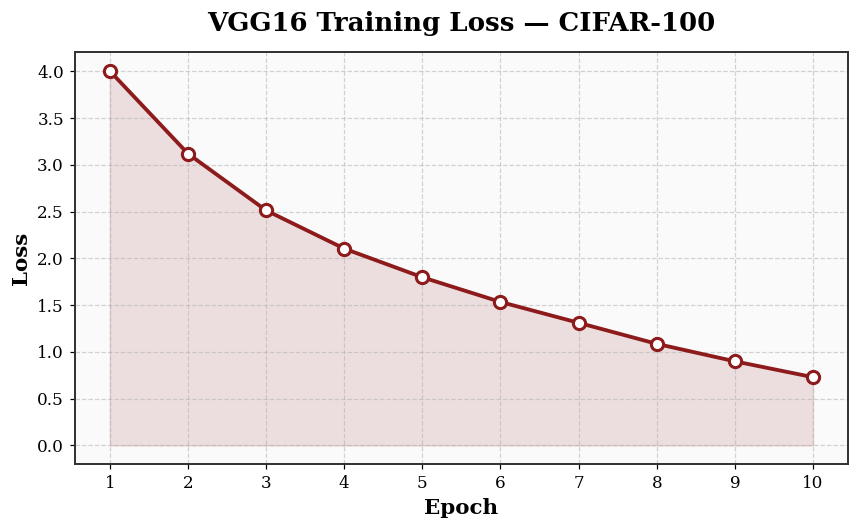

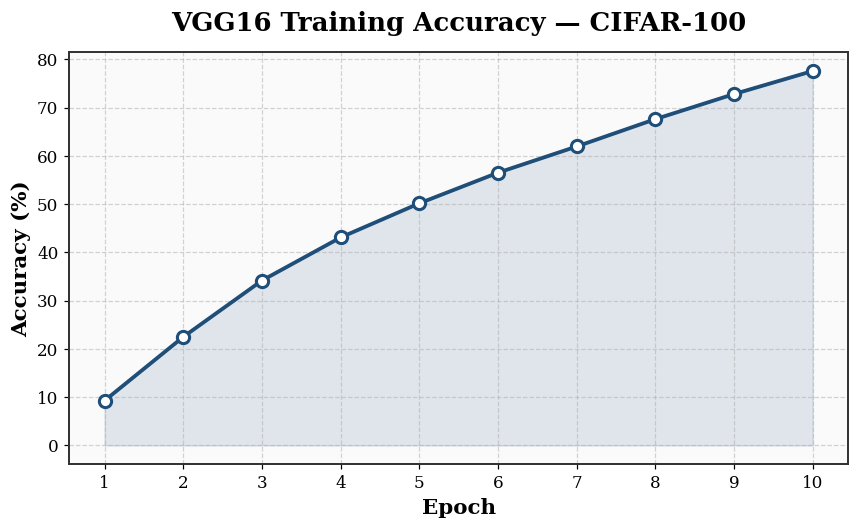

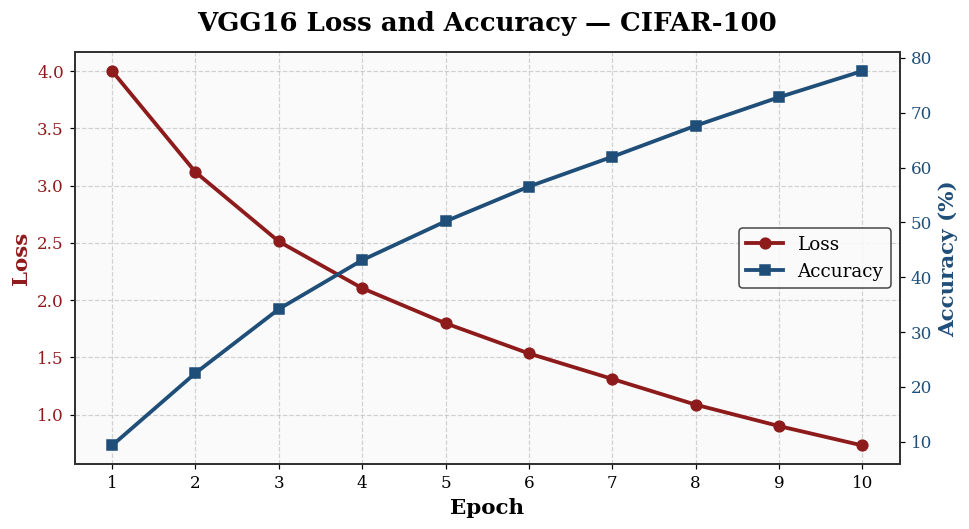

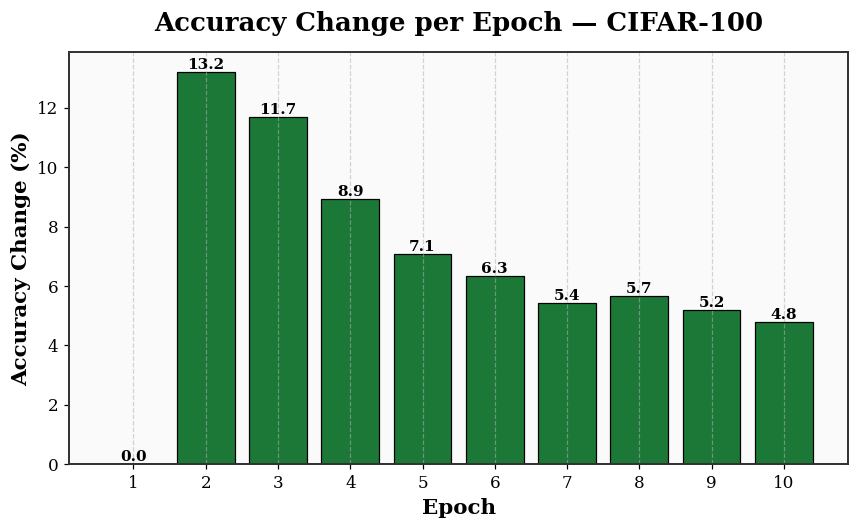

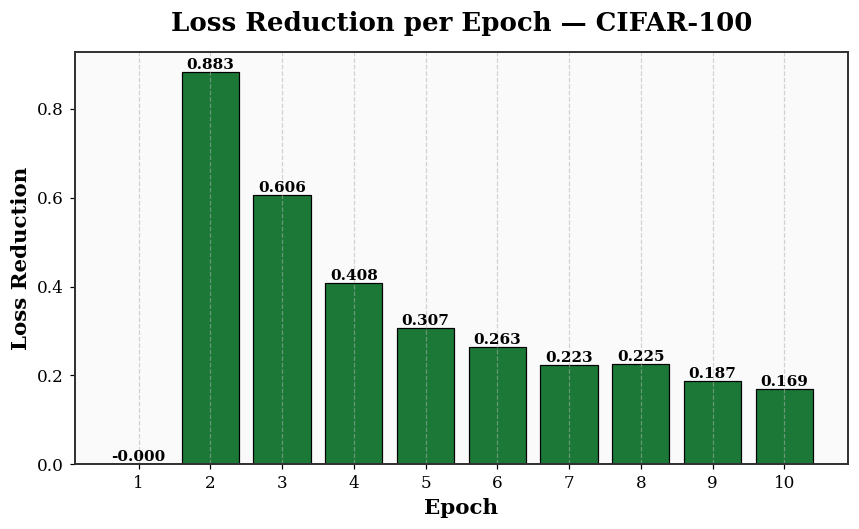

In [ ]:
# ============================================
# CIFAR-100 visualisations
# ============================================

plot_vgg_training_history(
    cifar100_vgg_losses,
    cifar100_vgg_accuracies,
    "CIFAR-100"
)


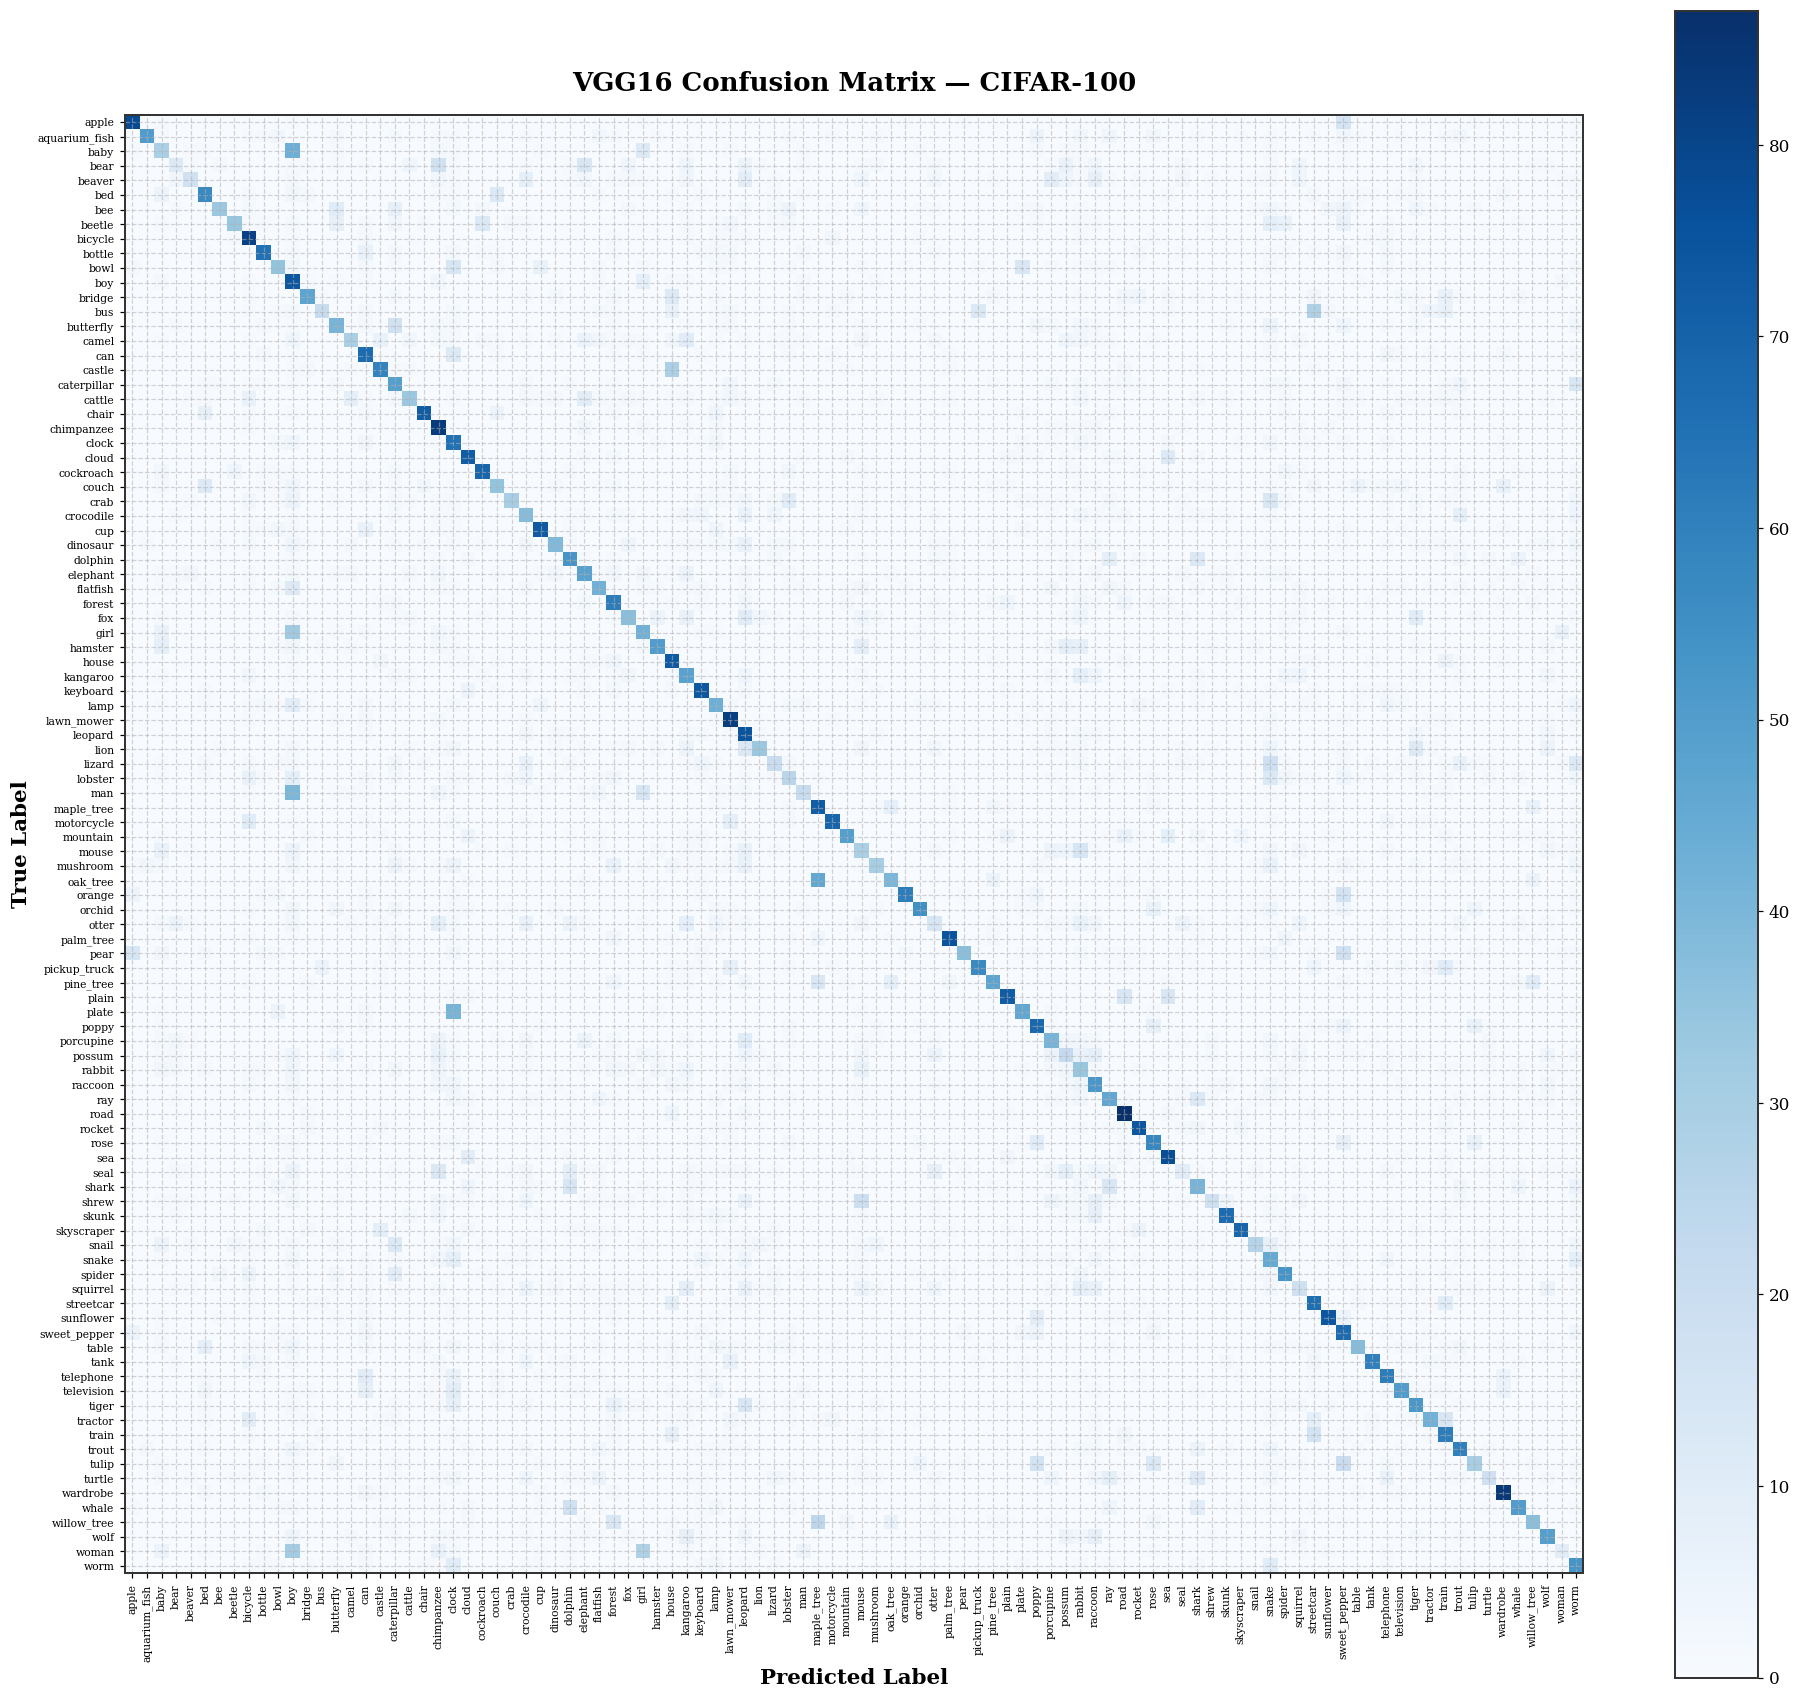

In [ ]:
plot_vgg_confusion_matrix(
    cifar100_vgg_results["confusion_matrix"],
    cifar100_classes,
    "CIFAR-100"
)

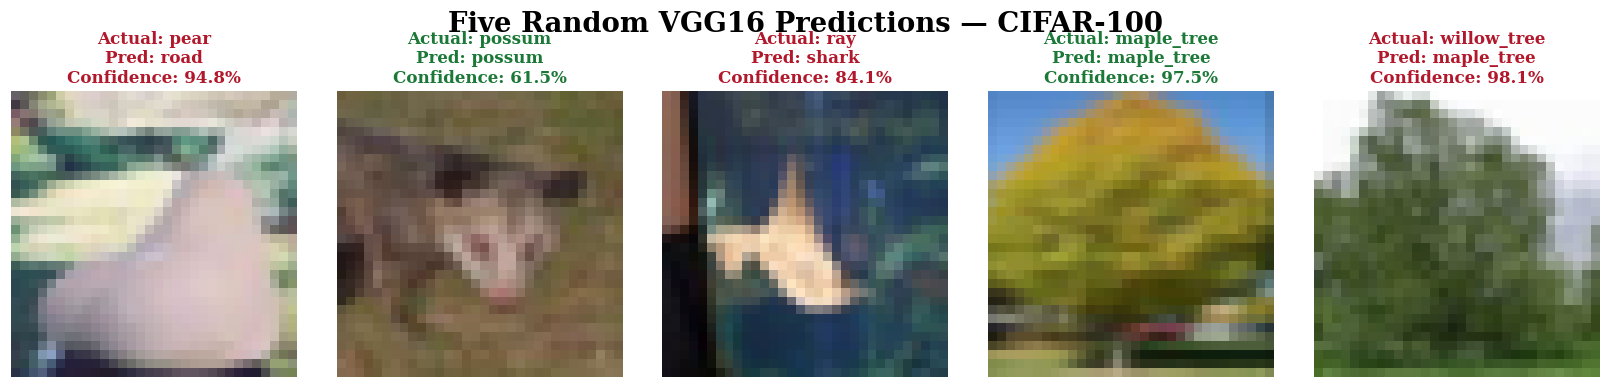

In [ ]:
random_vgg_predictions(
    cifar100_vgg_model,
    cifar100_test,
    cifar100_classes,
    "CIFAR-100"
)

## Section 15 — Q2 Results Table

In [ ]:
# ============================================
# Q2 results comparison table
# ============================================

q2_results = {
    "Dataset": [
        "MNIST",
        "CIFAR-10",
        "CIFAR-100"
    ],

    "Accuracy (%)": [
        mnist_vgg_results["accuracy"] * 100,
        cifar10_vgg_results["accuracy"] * 100,
        cifar100_vgg_results["accuracy"] * 100
    ],

    "Precision (%)": [
        mnist_vgg_results["precision"] * 100,
        cifar10_vgg_results["precision"] * 100,
        cifar100_vgg_results["precision"] * 100
    ],

    "Recall (%)": [
        mnist_vgg_results["recall"] * 100,
        cifar10_vgg_results["recall"] * 100,
        cifar100_vgg_results["recall"] * 100
    ],

    "F1-score (%)": [
        mnist_vgg_results["f1"] * 100,
        cifar10_vgg_results["f1"] * 100,
        cifar100_vgg_results["f1"] * 100
    ],

    "Training Time (s)": [
        mnist_vgg_training_time,
        cifar10_vgg_training_time,
        cifar100_vgg_training_time
    ]
}

q2_results_df = pd.DataFrame(q2_results)

q2_results_df.round(2)


,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,99.42,99.41,99.42,99.42,553.84
1,CIFAR-10,81.67,82.25,81.67,81.58,445.08
2,CIFAR-100,49.32,54.24,49.32,49.04,431.21


## Section 16 — Q2 Performance Comparison

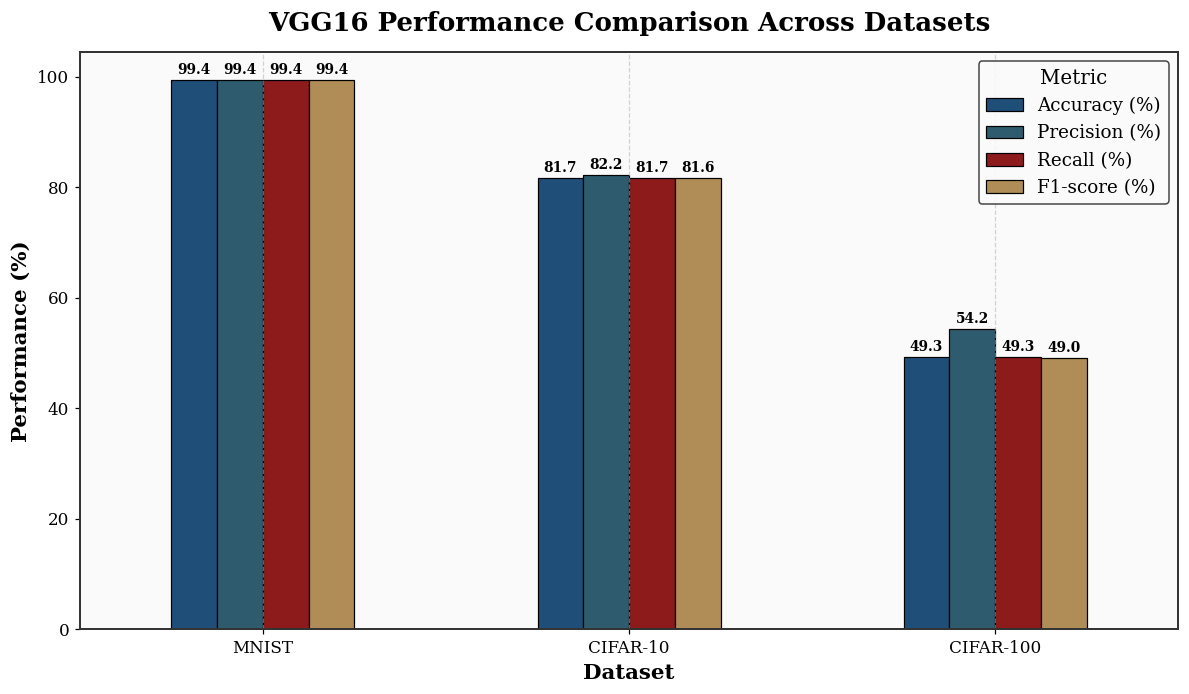

In [ ]:
# ============================================
# Q2 performance comparison graph
# ============================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

ax = q2_results_df.set_index("Dataset")[metrics].plot(
    kind="bar",
    figsize=(11, 6.5),
    color=comparison_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9, fontweight="bold", padding=2)

plt.title("VGG16 Performance Comparison Across Datasets", fontsize=17, fontweight="bold", pad=14)
plt.xlabel("Dataset")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.show()


## Section 17 — Effect of Convolutional Layers


In [ ]:
# The number of convolutional layers affects the representational capacity of a CNN. Deeper convolutional networks can learn
# increasingly complex hierarchical features. To investigate this effect, simplified VGG-style models with different numbers of
# convolutional blocks are compared.

# The experiment uses the CIFAR-10 dataset while keeping the optimizer, learning rate, batch size and number of epochs unchanged.

### Convolutional Depth — Model Definition

In [ ]:
# ============================================
# VGG model for convolutional-layer experiment
# ============================================

class VGGFlexible(nn.Module):

    def __init__(self, num_classes, num_blocks=5):

        super(VGGFlexible, self).__init__()

        block_channels = [64, 128, 256, 512, 512]

        layers = []
        in_channels = 3

        for block_index in range(num_blocks):

            out_channels = block_channels[block_index]

            # Two convolutional layers per block
            layers.append(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            layers.append(nn.ReLU(inplace=True))

            layers.append(
                nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            layers.append(nn.ReLU(inplace=True))

            layers.append(
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(
            in_channels,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x


### Convolutional Depth — Experiment

In [ ]:
# ============================================
# Compare convolutional depth
# ============================================

conv_layer_configs = [2, 3, 4, 5]

conv_layer_results = []

for num_blocks in conv_layer_configs:

    print(f"\nTesting {num_blocks} convolutional blocks")

    model = VGGFlexible(
        num_classes=10,
        num_blocks=num_blocks
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE
    )

    losses, accuracies, training_time = train_vgg_model(
        model,
        cifar10_train_loader,
        criterion,
        optimizer,
        epochs=EPOCHS
    )

    results = evaluate_vgg_model(
        model,
        cifar10_test_loader
    )

    conv_layer_results.append({
        "Convolutional Blocks": num_blocks,
        "Accuracy (%)": results["accuracy"] * 100,
        "Precision (%)": results["precision"] * 100,
        "Recall (%)": results["recall"] * 100,
        "F1-score (%)": results["f1"] * 100,
        "Training Time (s)": training_time
    })

conv_layer_df = pd.DataFrame(conv_layer_results)

conv_layer_df.round(2)



Testing 2 convolutional blocks
Epoch [1/10] Loss: 2.1508 Accuracy: 19.62%
Epoch [2/10] Loss: 1.8915 Accuracy: 28.71%
Epoch [3/10] Loss: 1.7253 Accuracy: 34.80%
Epoch [4/10] Loss: 1.6395 Accuracy: 38.53%
Epoch [5/10] Loss: 1.5687 Accuracy: 41.59%
Epoch [6/10] Loss: 1.5121 Accuracy: 44.03%
Epoch [7/10] Loss: 1.4536 Accuracy: 47.00%
Epoch [8/10] Loss: 1.3980 Accuracy: 49.34%
Epoch [9/10] Loss: 1.3444 Accuracy: 51.66%
Epoch [10/10] Loss: 1.2918 Accuracy: 54.00%

Testing 3 convolutional blocks
Epoch [1/10] Loss: 2.2887 Accuracy: 12.26%
Epoch [2/10] Loss: 1.9712 Accuracy: 25.20%
Epoch [3/10] Loss: 1.7489 Accuracy: 33.75%
Epoch [4/10] Loss: 1.5973 Accuracy: 40.44%
Epoch [5/10] Loss: 1.4814 Accuracy: 45.28%
Epoch [6/10] Loss: 1.3718 Accuracy: 49.79%
Epoch [7/10] Loss: 1.2722 Accuracy: 54.17%
Epoch [8/10] Loss: 1.1864 Accuracy: 57.43%
Epoch [9/10] Loss: 1.1157 Accuracy: 60.08%
Epoch [10/10] Loss: 1.0599 Accuracy: 62.04%

Testing 4 convolutional blocks
Epoch [1/10] Loss: 2.3026 Accuracy: 10.04%

,Convolutional Blocks,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,2,52.43,56.94,52.43,53.13,214.15
1,3,63.97,64.53,63.97,63.54,219.51
2,4,59.62,61.47,59.62,59.18,264.75
3,5,10.00,1.00,10.00,1.82,325.13


### Convolutional Depth — Comparison Graph

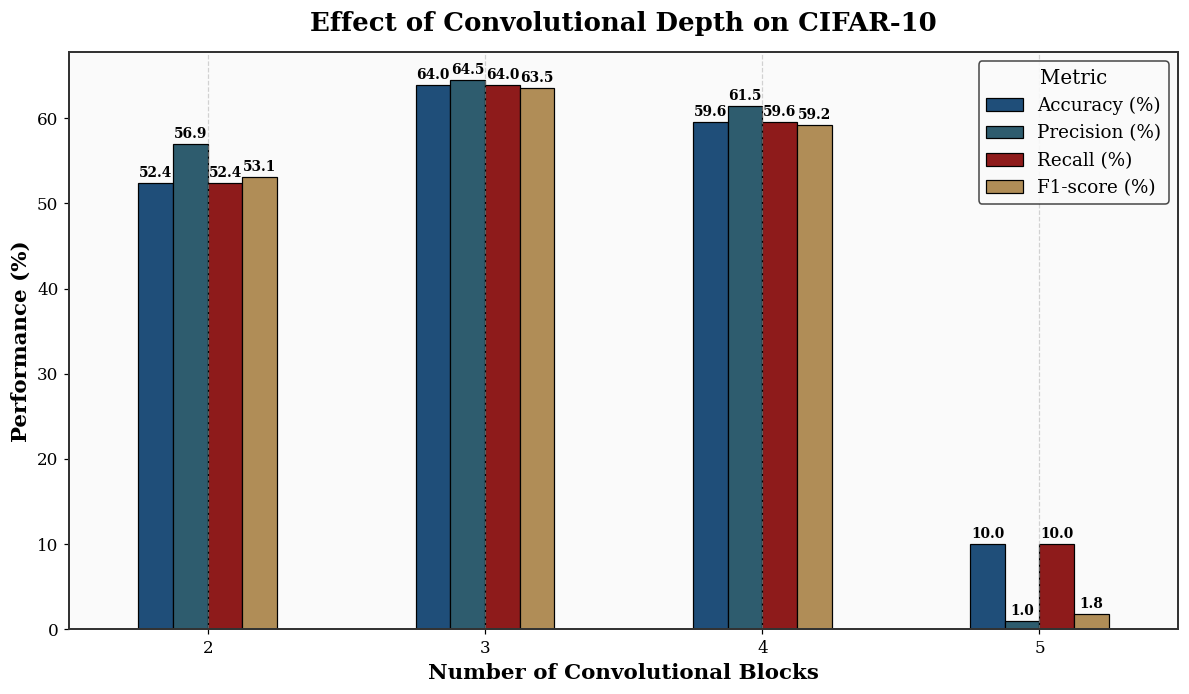

In [ ]:
# ============================================
# Convolutional depth comparison graph
# ============================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

ax = conv_layer_df.set_index(
    "Convolutional Blocks"
)[metrics].plot(
    kind="bar",
    figsize=(11, 6.5),
    color=comparison_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9, fontweight="bold", padding=2)

plt.title("Effect of Convolutional Depth on CIFAR-10", fontsize=17, fontweight="bold", pad=14)
plt.xlabel("Number of Convolutional Blocks")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.show()


## Section 18 — Effect of Number of Filters

In [ ]:
# The number of filters controls how many feature maps are learned by each convolutional layer.
# More filters increase the representational capacity of a CNN but also increase the number of trainable parameters
# and computational requirements.

# A smaller VGG-style architecture is compared with progressively larger filter configurations using CIFAR-10.

### Filter Size — Model Definition

In [ ]:
# ============================================
#  Flexible filter-size VGG model
# ============================================

class VGGFilterExperiment(nn.Module):

    def __init__(self, num_classes, base_filters=16):

        super(VGGFilterExperiment, self).__init__()

        channels = [
            base_filters,
            base_filters * 2,
            base_filters * 4
        ]

        layers = []
        in_channels = 3

        for out_channels in channels:

            layers.append(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            layers.append(nn.ReLU(inplace=True))

            layers.append(
                nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            layers.append(nn.ReLU(inplace=True))

            layers.append(
                nn.MaxPool2d(2, 2)
            )

            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(
            in_channels,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x


### Filter Size — Experiment

In [ ]:
# ============================================
#  Compare filter sizes
# ============================================

filter_configs = [16, 32, 64]

filter_results = []

for base_filters in filter_configs:

    print(f"\nTesting base filters: {base_filters}")

    model = VGGFilterExperiment(
        num_classes=10,
        base_filters=base_filters
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE
    )

    losses, accuracies, training_time = train_vgg_model(
        model,
        cifar10_train_loader,
        criterion,
        optimizer,
        epochs=EPOCHS
    )

    results = evaluate_vgg_model(
        model,
        cifar10_test_loader
    )

    parameter_count = sum(
        p.numel() for p in model.parameters()
    )

    filter_results.append({
        "Base Filters": base_filters,
        "Accuracy (%)": results["accuracy"] * 100,
        "Precision (%)": results["precision"] * 100,
        "Recall (%)": results["recall"] * 100,
        "F1-score (%)": results["f1"] * 100,
        "Training Time (s)": training_time,
        "Parameters": parameter_count
    })

filter_df = pd.DataFrame(filter_results)

filter_df.round(2)



Testing base filters: 16
Epoch [1/10] Loss: 2.3030 Accuracy: 10.22%
Epoch [2/10] Loss: 2.3011 Accuracy: 12.00%
Epoch [3/10] Loss: 2.1983 Accuracy: 17.20%
Epoch [4/10] Loss: 1.8847 Accuracy: 26.70%
Epoch [5/10] Loss: 1.7638 Accuracy: 32.15%
Epoch [6/10] Loss: 1.6869 Accuracy: 35.99%
Epoch [7/10] Loss: 1.5983 Accuracy: 40.31%
Epoch [8/10] Loss: 1.5021 Accuracy: 44.64%
Epoch [9/10] Loss: 1.4071 Accuracy: 48.66%
Epoch [10/10] Loss: 1.3190 Accuracy: 51.99%

Testing base filters: 32
Epoch [1/10] Loss: 2.3001 Accuracy: 10.46%
Epoch [2/10] Loss: 2.0915 Accuracy: 21.09%
Epoch [3/10] Loss: 1.8150 Accuracy: 30.61%
Epoch [4/10] Loss: 1.6937 Accuracy: 36.37%
Epoch [5/10] Loss: 1.6007 Accuracy: 40.64%
Epoch [6/10] Loss: 1.4929 Accuracy: 44.83%
Epoch [7/10] Loss: 1.3873 Accuracy: 49.12%
Epoch [8/10] Loss: 1.2841 Accuracy: 53.47%
Epoch [9/10] Loss: 1.2069 Accuracy: 56.47%
Epoch [10/10] Loss: 1.1372 Accuracy: 59.37%

Testing base filters: 64
Epoch [1/10] Loss: 2.2587 Accuracy: 13.81%
Epoch [2/10] Loss

,Base Filters,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s),Parameters
0,16,53.44,54.22,53.44,52.60,182.94,72730
1,32,61.34,62.19,61.34,61.00,218.24,288298
2,64,60.04,63.08,60.04,59.99,221.46,1147978


### Filter Size — Comparison Graph

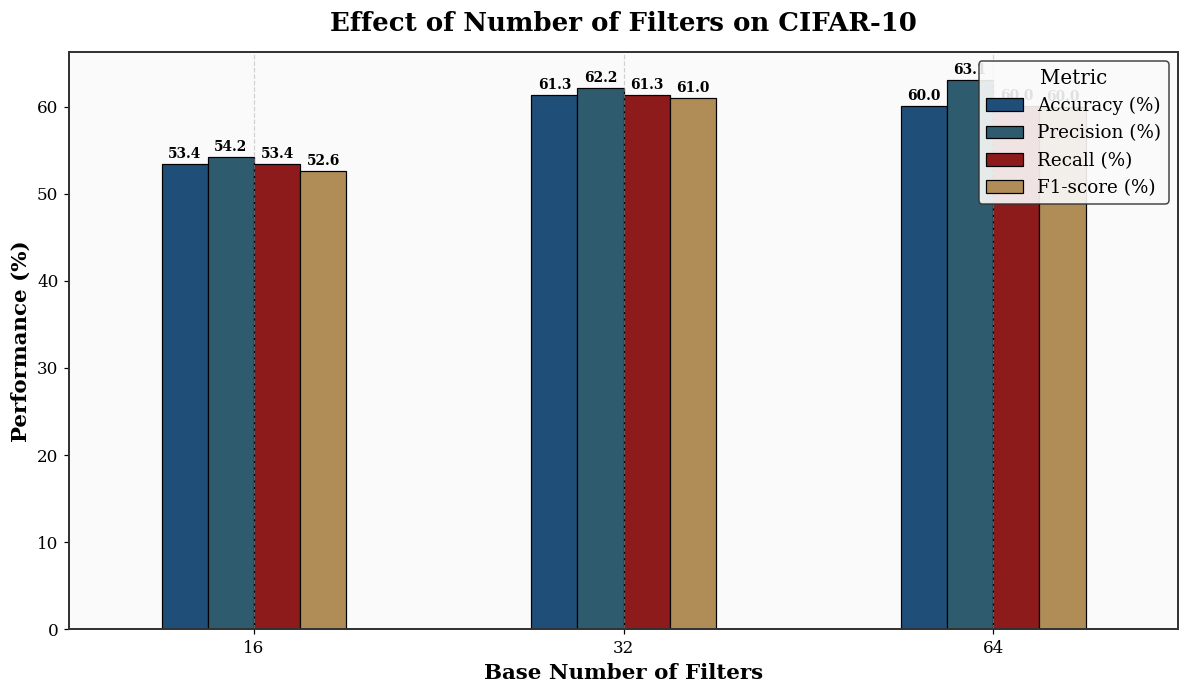

In [ ]:
# ============================================
#  Filter comparison graph
# ============================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

ax = filter_df.set_index(
    "Base Filters"
)[metrics].plot(
    kind="bar",
    figsize=(11, 6.5),
    color=comparison_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9, fontweight="bold", padding=2)

plt.title("Effect of Number of Filters on CIFAR-10", fontsize=17, fontweight="bold", pad=14)
plt.xlabel("Base Number of Filters")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.show()


### Filter Size — Parameter Count

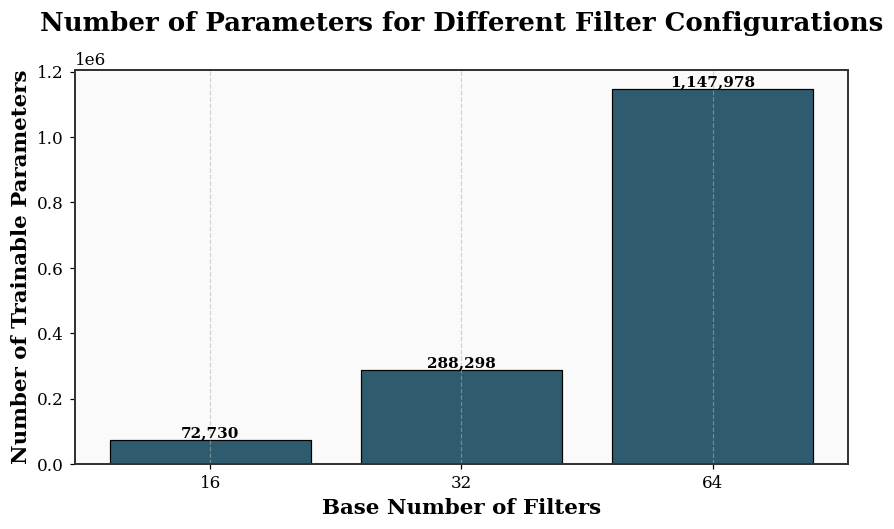

In [ ]:
# ============================================
# Parameter count comparison
# ============================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    filter_df["Base Filters"].astype(str),
    filter_df["Parameters"],
    color=PALETTE["bar_primary"],
    edgecolor="black",
    linewidth=0.8,
)

for bar, value in zip(bars, filter_df["Parameters"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{value:,.0f}", ha="center", va="bottom",
        fontsize=10, fontweight="bold",
    )

plt.title("Number of Parameters for Different Filter Configurations", fontsize=17, fontweight="bold", pad=14)
plt.xlabel("Base Number of Filters")
plt.ylabel("Number of Trainable Parameters")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


In [ ]:
q2_results_df.round(2)

,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,99.42,99.41,99.42,99.42,553.84
1,CIFAR-10,81.67,82.25,81.67,81.58,445.08
2,CIFAR-100,49.32,54.24,49.32,49.04,431.21


In [ ]:
conv_layer_df.round(2)

,Convolutional Blocks,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,2,52.43,56.94,52.43,53.13,214.15
1,3,63.97,64.53,63.97,63.54,219.51
2,4,59.62,61.47,59.62,59.18,264.75
3,5,10.00,1.00,10.00,1.82,325.13


In [ ]:
filter_df.round(2)

,Base Filters,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s),Parameters
0,16,53.44,54.22,53.44,52.60,182.94,72730
1,32,61.34,62.19,61.34,61.00,218.24,288298
2,64,60.04,63.08,60.04,59.99,221.46,1147978


## Section 19 — Q2 Analysis

In [ ]:
# VGG16 achieved the best performance on MNIST with 99.42% accuracy, followed by CIFAR-10 at 81.67% and CIFAR-100 at 49.32%.
# The lower performance on CIFAR-10 and CIFAR-100 is due to their more complex images and larger number of classes.

# The convolutional-depth experiment showed that three blocks performed best with 63.97% accuracy. Increasing to four blocks
# reduced accuracy to 59.62%, while five blocks dropped to 10.00%. In the filter experiment, 32 base filters achieved the
# best accuracy of 61.34%. Increasing to 64 filters reduced accuracy slightly to 60.04% while greatly increasing the number of
# parameters. Therefore, more layers or filters do not always improve performance.


## Section 20 — Q2 Conclusion

In [ ]:
# Overall, VGG16 performed well on the three image classification tasks, with the best result on MNIST.
# The experiments showed that increasing convolutional depth or filter count can improve feature learning, but excessive model
# complexity does not necessarily improve performance. Three convolutional blocks and 32 base filters provided the best
# results in the tested configurations.
